In [3]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("churn.csv")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.drop('customerID', axis=1, inplace=True)

In [8]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [10]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = "coerce")

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [13]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,0
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,0
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
9,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,0


In [14]:
df.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [15]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [16]:
df = pd.get_dummies(df, drop_first=True)

In [17]:
df.select_dtypes(include="object").columns

Index([], dtype='object')

In [18]:
df.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   gender_Male                            7043 non-null   bool   
 6   Partner_Yes                            7043 non-null   bool   
 7   Dependents_Yes                         7043 non-null   bool   
 8   PhoneService_Yes                       7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10  MultipleLines_Yes                      7043 non-null   bool   
 11  Inte

In [20]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

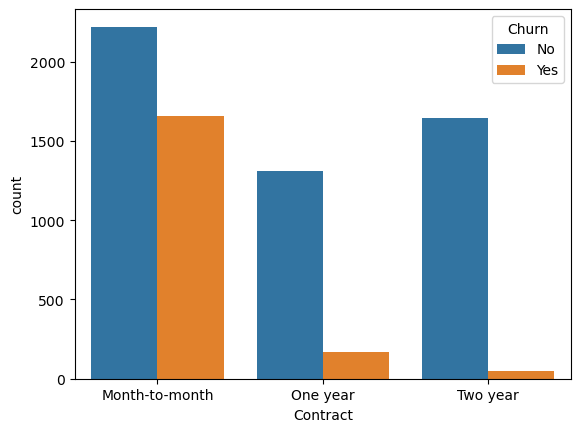

In [21]:
df_original = pd.read_csv("C:/Users/Roh00/Downloads/customer_churn_prediction/churn.csv")
sns.countplot(x="Contract", hue="Churn", data= df_original)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

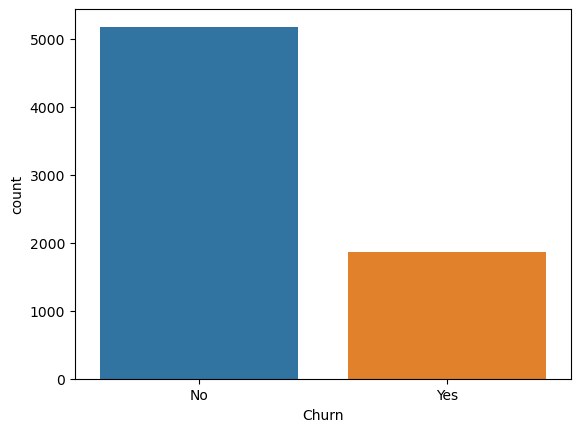

In [22]:
sns.countplot(x='Churn', data=df_original, hue='Churn')
plt.show

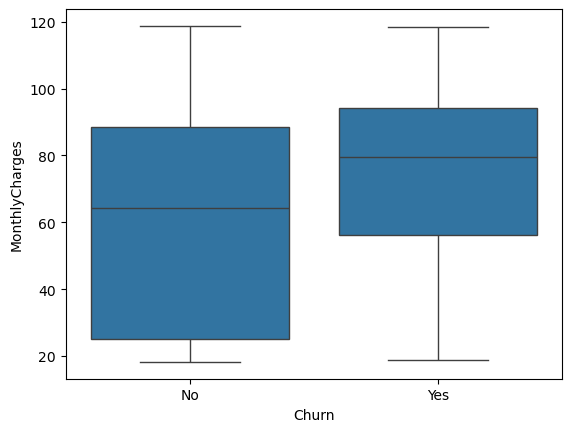

In [23]:
sns.boxplot(x="Churn", y="MonthlyCharges", data= df_original)
plt.show()

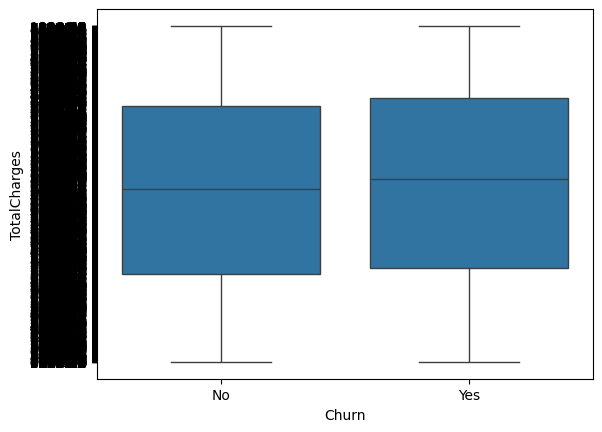

In [24]:
sns.boxplot(x="Churn", y="TotalCharges", data=df_original)
plt.show()

Categorical Features vs Churn

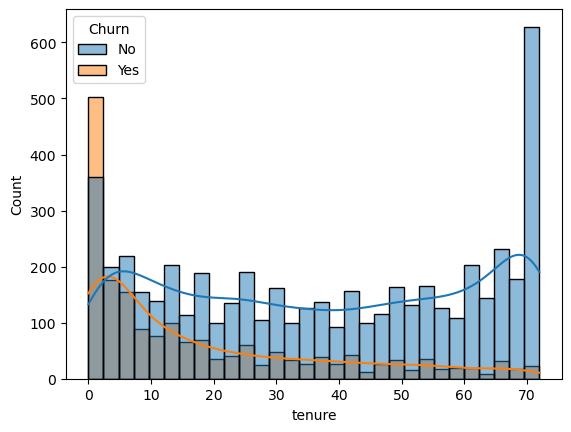

In [25]:
sns.histplot(data=df_original, x="tenure", hue="Churn", bins=30, kde=True)
plt.show()

<Axes: xlabel='tenure', ylabel='Count'>

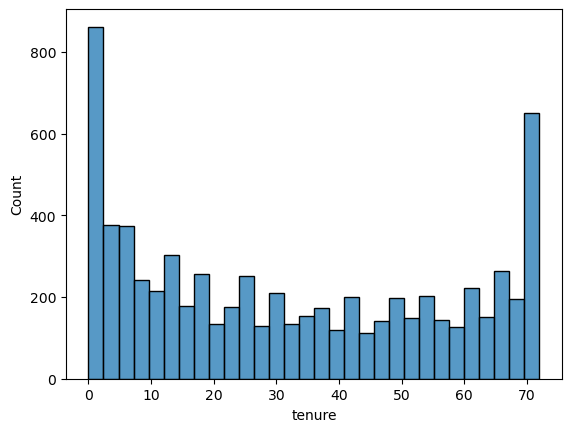

In [26]:
sns.histplot(df_original["tenure"], bins=30)

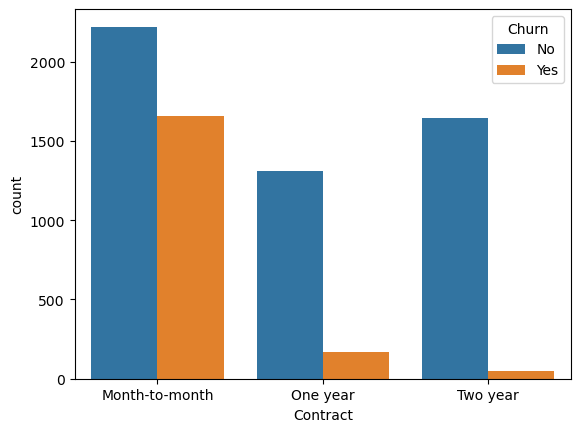

In [27]:
sns.countplot(data=df_original,x="Contract",hue="Churn")
plt.show()

In [28]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [29]:
df.dropna(inplace=True)

In [30]:
df = pd.get_dummies(df, drop_first=True)

In [31]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [35]:
y_pred = model.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:",accuracy)


Accuracy: 0.7874911158493249


In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print("-----------")
print(cm)

Confusion Matrix:
-----------
[[915 118]
 [181 193]]


In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [40]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [41]:
rf_pred = rf_model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, rf_pred)
print("Accuracy:",accuracy)

Accuracy: 0.7846481876332623


In [43]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_pred)
print("Confusion Matrix:")
print("-----------")
print(rf_cm)

Confusion Matrix:
-----------
[[927 106]
 [197 177]]


In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [45]:
from imblearn.over_sampling import SMOTE

In [46]:
smote = SMOTE(random_state=42)

In [47]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

C:\Users\roh00\anaconda3\envs\tf\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [48]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

Churn
0    4130
1    1495
Name: count, dtype: int64
Churn
1    4130
0    4130
Name: count, dtype: int64


In [49]:
model_smote = LogisticRegression()

model_smote.fit(X_train_smote, y_train_smote)

LogisticRegression()

In [50]:
smote_pred = model_smote.predict(X_test)

print(classification_report(y_test, smote_pred))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



In [51]:
feature_names = X.columns

In [52]:
importance = model_smote.coef_[0]

In [53]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

In [54]:
feature_importance

,Feature,Importance
0,SeniorCitizen,0.074525
1,tenure,-1.588884
2,MonthlyCharges,-1.217750
3,TotalCharges,0.886783
4,gender_Male,-0.012858
5,Partner_Yes,0.022618
6,Dependents_Yes,-0.112454
7,PhoneService_Yes,0.024556
8,MultipleLines_No phone service,-0.024556
9,MultipleLines_Yes,0.207805


In [55]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [56]:
feature_importance

,Feature,Importance
3,TotalCharges,0.886783
10,InternetService_Fiber optic,0.854443
23,StreamingMovies_Yes,0.347187
21,StreamingTV_Yes,0.282805
9,MultipleLines_Yes,0.207805
28,PaymentMethod_Electronic check,0.155188
26,PaperlessBilling_Yes,0.147635
17,DeviceProtection_Yes,0.081291
0,SeniorCitizen,0.074525
7,PhoneService_Yes,0.024556


In [57]:
print(feature_importance.head(10))

                           Feature  Importance
3                     TotalCharges    0.886783
10     InternetService_Fiber optic    0.854443
23             StreamingMovies_Yes    0.347187
21                 StreamingTV_Yes    0.282805
9                MultipleLines_Yes    0.207805
28  PaymentMethod_Electronic check    0.155188
26            PaperlessBilling_Yes    0.147635
17            DeviceProtection_Yes    0.081291
0                    SeniorCitizen    0.074525
7                 PhoneService_Yes    0.024556


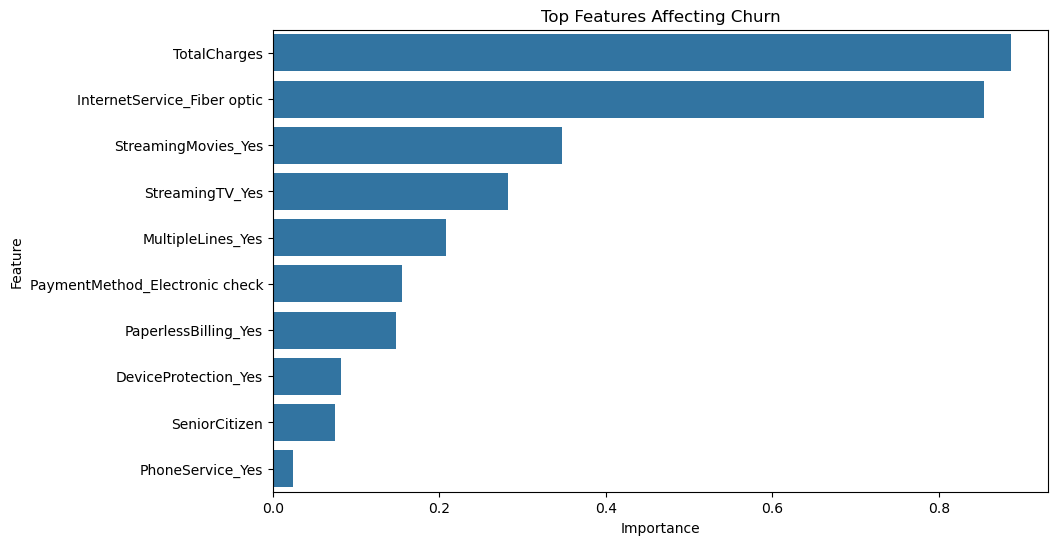

In [58]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top Features Affecting Churn")
plt.show()

In [59]:
feature_importance = feature_importance.sort_values(
    by="Importance"
)

In [60]:
feature_importance.head(10)

,Feature,Importance
1,tenure,-1.588884
2,MonthlyCharges,-1.217750
25,Contract_Two year,-0.616120
24,Contract_One year,-0.345621
13,OnlineSecurity_Yes,-0.124596
19,TechSupport_Yes,-0.114498
6,Dependents_Yes,-0.112454
16,DeviceProtection_No internet service,-0.102435
12,OnlineSecurity_No internet service,-0.102435
18,TechSupport_No internet service,-0.102435


In [61]:
import joblib

joblib.dump(model_smote, "churn_model.pkl")

['churn_model.pkl']

In [62]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [63]:
simple_features = ["tenure", "MonthlyCharges", "TotalCharges"]

X_simple = df[simple_features]
y = df["Churn"]

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [66]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [67]:
joblib.dump(model, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']